<a href="https://colab.research.google.com/github/Moquiuti/LangGraph_Orquestrando_agentes_e_multiagentes/blob/main/Agente_Langgraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q -U langgraph
!pip install -q -U langchain
!pip install -q -U langchain-core
!pip install -q -U langchain-google-genai
!pip install -q -U langchain-tavily
!pip install -q -U python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.3/234.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 1.2.15 requires langgraph<1.2.0,>=1.1.5, but you have langgraph 1.2.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.1/114.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 2.4 MB/s eta 0:00:00


In [2]:
import os
from typing import TypedDict, Annotated, Sequence

from dotenv import load_dotenv

from langchain_core.messages import (
    BaseMessage,
    HumanMessage,
    AIMessage,
    ToolMessage
)

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_tavily import TavilySearch

from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages

In [3]:
try:
    from google.colab import userdata

    os.environ["GEMINI_API_KEY"] = userdata.get("GEMINI_API_KEY")
    os.environ["TAVILY_API_KEY"] = userdata.get("TAVILY_API_KEY")

    print("API Keys carregadas pelos Secrets do Colab.")

except Exception:
    load_dotenv()
    print("Tentando carregar API Keys via arquivo .env.")

API Keys carregadas pelos Secrets do Colab.


In [4]:
llm_teste = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

resposta = llm_teste.invoke("Responda apenas: Hello World")
print(resposta.content)

Hello World


In [5]:
tavily_teste = TavilySearch(
    max_results=3
)

resultado_busca = tavily_teste.invoke({
    "query": "previsão do tempo em Campo Grande MS hoje"
})

print(resultado_busca)

{'query': 'previsão do tempo em Campo Grande MS hoje', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.climatempo.com.br/previsao-do-tempo/cidade/212/campogrande-ms', 'title': 'Clima e Previsão do Tempo Hoje em Campo Grande (MS)', 'content': '# Previsão do Tempo para Hoje em 02/05 Campo Grande (MS) Campo Grande - MS Ícone de favorito. Sol com muitas nuvens durante o dia e períodos de céu nublado. ## Consulte a previsão do tempo para Campo Grande - MS e qualquer lugar do Brasil. ## Clima, previsão do tempo hoje e notícias em Campo Grande - MS. ### Qual a previsão do tempo para hoje em Campo Grande - MS? A previsão do tempo para hoje é de temperaturas entre 20° e 31° e sem possibilidade de chuva em Campo Grande - MS. ### Qual a temperatura de hoje em Campo Grande - MS? A temperatura máxima é de 31° hoje em Campo Grande - MS. Para o mês de maio, a média mensal de chuva é de 78 mm na cidade Campo Grande - MS. A previsão indica chuva volumosa para

In [6]:
#estado do agente
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [7]:
search_tool = TavilySearch(
    max_results=3,
    topic="general"
)

tools = [search_tool]

Criar o LLM Gemini
Vincular ferramentas ao LLM
Chamar o modelo
Executar ações
Verificar se ainda existem ferramentas para chamar
Construir o grafo

In [8]:
class Agent:
    def __init__(self, model, tools):
        self.model = model.bind_tools(tools)
        self.tools = {tool.name: tool for tool in tools}

        graph = StateGraph(AgentState)

        graph.add_node("llm", self.call_llm)
        graph.add_node("action", self.take_action)

        graph.set_entry_point("llm")

        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {
                True: "action",
                False: END
            }
        )

        graph.add_edge("action", "llm")

        self.graph = graph.compile()

    def call_llm(self, state: AgentState):
        messages = state["messages"]

        response = self.model.invoke(messages)

        return {
            "messages": [response]
        }

    def exists_action(self, state: AgentState):
        result = state["messages"][-1]

        return len(result.tool_calls) > 0

    def take_action(self, state: AgentState):
        tool_calls = state["messages"][-1].tool_calls
        results = []

        for tool_call in tool_calls:
            tool_name = tool_call["name"]
            tool_args = tool_call["args"]
            tool_id = tool_call["id"]

            print(f"Chamando ferramenta: {tool_name}")
            print(f"Argumentos: {tool_args}")

            if tool_name not in self.tools:
                result = f"Ferramenta {tool_name} não encontrada."
            else:
                result = self.tools[tool_name].invoke(tool_args)

            results.append(
                ToolMessage(
                    tool_call_id=tool_id,
                    name=tool_name,
                    content=str(result)
                )
            )

        return {
            "messages": results
        }

In [9]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

agent = Agent(
    model=llm,
    tools=tools
)

In [10]:
def executar_agente(pergunta: str):
    resultado = agent.graph.invoke({
        "messages": [HumanMessage(content=pergunta)]
    })

    resposta_final = resultado["messages"][-1]

    print("\n=== RESPOSTA FINAL ===")
    print(resposta_final.content)

    return resultado

In [11]:
resultado = executar_agente(
    "Pesquise na internet e me diga a previsão do tempo em Campo Grande MS hoje."
)

Chamando ferramenta: tavily_search
Argumentos: {'query': 'previsão do tempo Campo Grande MS hoje'}

=== RESPOSTA FINAL ===
[{'type': 'text', 'text': 'A previsão do tempo para Campo Grande, MS, hoje (13 de maio) indica sol com muitas nuvens e períodos de céu nublado, mas sem previsão de chuva. As temperaturas devem variar entre 14°C e 26°C. Atualmente, a temperatura está em torno de 26°C, com expectativa de queda para cerca de 18°C mais tarde.', 'extras': {'signature': 'CvELAQw51sdppzx4JP2zSiHdHa26YETRNFRhTdJHNIt1jsEXmmjjO/Ccmw3DO5T3gHFvVFq4hvmflupoYB/mNHTupzUW2YmiHIHEtd37bidJmSiiflxCjMegGLbwoOUjFNUVFG8a/93IilTsOwK129ioV4nR3AVFX0rfLQ9+87o2ZB1LTG9j4Hv3HUCCuBIVmfpEq+YR4Op5L53V1Bvs5VOSwEV6rdlPfKqX82xoURPwWwLo27UEBGAtTN951cMU+K/MXhJFnmM0s7FZneXuHAGQzX+crylz9Pu+n5HjLfdEUjrcSJNdmzazZXm7UVXRdroN7kxAtV9jjNRmlCASaYaDa9lj2PVD7+S2JuBzeIRJN1pxuAiJzs4pZMMnGsxdM/bmlb3NxbFRvTAo11CDtrRo7rRl1gEcKF2G3dk8wYhoxKX3V1jGff9eoX4Y6+uIpQ0JWJ8WaEzY3+RxaAks4Z2H0HfGEPyYfMdYAxAa8aib1Bao0UeI2hKo0PWHdlLOjZeKshoA93kZ5V

Aqui o fluxo a cima é:

Usuário pergunta

↓

LLM percebe que precisa buscar informação atual

↓

LLM chama Tavily

↓

Tavily retorna resultado

↓

LLM interpreta a observação

↓

LLM responde


In [12]:
resultado = executar_agente(
    "Pesquise quais são as principais novidades recentes sobre LangGraph e me resuma em português."
)

Chamando ferramenta: tavily_search
Argumentos: {'query': 'LangGraph recent updates', 'time_range': 'month'}

=== RESPOSTA FINAL ===
[{'type': 'text', 'text': 'As principais novidades recentes sobre LangGraph incluem:\n\n*   **LangGraph checkpoint 4.0.3:** Uma atualização de manutenção que corrige a recuperação de blobs JSON lc=2 para tipos seguros sem uma lista de permissões.\n*   **Pacote `@langchain/langgraph`:** A versão mais recente é a 1.3.0, publicada há 7 dias.\n*   **Compatibilidade com LangGraph v1.0:** Houve uma grande mudança no `langchain/langgraph-sdk` para garantir a compatibilidade com a versão 1.0 do LangGraph.', 'extras': {'signature': 'CtQDAQw51sfctzacH68nT8ocEJidmcv9WdksRW74ay8vLlI+pq7blYn+57TJ7ZXlfFXw1I3VVpGOYkAtOPSCDraUd950ledlxKcx+/XmcJs5MuH9BOHoFIbLAsk4WS2s0hlJSdKu0kkZHV6VOOoGwpKvyTIUtyeSO4ro1xG3tw82VF4fcRfILLnkS2pl864ZEhWUBZUns+2wZjoys++jZ5IABZNRwHpiAM8XrmNOO3bRbsNhS8VZoE0GNTWEteqFDXmAGil6KleynIjX24qm81AvGV2irb1H5+WVAl6TnZ1n4SjYIvtER94jqEuNJu/npJDspMuB3Ht+55Rj2f

In [13]:
resultado = executar_agente(
    "Pesquise a previsão do tempo em Campo Grande MS hoje e também as principais notícias recentes sobre inteligência artificial."
)

Chamando ferramenta: tavily_search
Argumentos: {'query': 'previsão do tempo Campo Grande MS hoje'}
Chamando ferramenta: tavily_search
Argumentos: {'query': 'notícias recentes inteligência artificial', 'topic': 'news', 'time_range': 'day'}

=== RESPOSTA FINAL ===
[{'type': 'text', 'text': 'Aqui está a previsão do tempo para Campo Grande, MS, hoje e as principais notícias recentes sobre inteligência artificial:\n\n**Previsão do Tempo em Campo Grande, MS (hoje, 13 de maio de 2026):**\n*   **Temperaturas:** Entre 20°C e 31°C.\n*   **Chuva:** Sem possibilidade de chuva.\n*   **Céu:** Sol com muitas nuvens durante o dia e períodos de céu nublado.\n*   **Vento:** Fraco a moderado, vindo do leste, com velocidades entre 9 e 17 km/h.\n\n**Principais Notícias Recentes sobre Inteligência Artificial:**\n*   **Segurança Corporativa:** O uso acelerado e desestruturado da inteligência artificial já é considerado um dos principais riscos corporativos no Brasil em 2026, segundo o portal Terra.com.br.\n*

In [14]:
for mensagem in resultado["messages"]:
    print("\n---", mensagem.type.upper(), "---")
    print(mensagem.content)


--- HUMAN ---
Pesquise a previsão do tempo em Campo Grande MS hoje e também as principais notícias recentes sobre inteligência artificial.

--- AI ---


--- TOOL ---
{'query': 'previsão do tempo Campo Grande MS hoje', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.climatempo.com.br/previsao-do-tempo/cidade/212/campogrande-ms', 'title': 'Clima e Previsão do Tempo Hoje em Campo Grande (MS)', 'content': '# Previsão do Tempo para Hoje em 02/05 Campo Grande (MS) Campo Grande - MS Ícone de favorito. Sol com muitas nuvens durante o dia e períodos de céu nublado. ## Consulte a previsão do tempo para Campo Grande - MS e qualquer lugar do Brasil. ## Clima, previsão do tempo hoje e notícias em Campo Grande - MS. ### Qual a previsão do tempo para hoje em Campo Grande - MS? A previsão do tempo para hoje é de temperaturas entre 20° e 31° e sem possibilidade de chuva em Campo Grande - MS. ### Qual a temperatura de hoje em Campo Grande - MS? A temperatura 

In [15]:
print("Agente LangGraph iniciado.")
print("Digite 'sair' para encerrar.\n")

while True:
    pergunta = input("Você: ")

    if pergunta.lower() in ["sair", "exit", "quit"]:
        print("Conversa encerrada.")
        break

    resultado = agent.graph.invoke({
        "messages": [HumanMessage(content=pergunta)]
    })

    resposta = resultado["messages"][-1]

    print("\nAgente:")
    print(resposta.content)
    print("\n" + "-" * 80 + "\n")

Agente LangGraph iniciado.
Digite 'sair' para encerrar.

Você: Me diga novamente sobre a previsão em campo grande
Chamando ferramenta: tavily_search
Argumentos: {'query': 'previsão do tempo Campo Grande'}

Agente:
[{'type': 'text', 'text': 'Para hoje, 2 de maio, em Campo Grande (MS), a previsão é de sol com muitas nuvens durante o dia e períodos de céu nublado. As temperaturas devem variar entre 20°C e 31°C, sem previsão de chuva.\n\nPara os próximos dias, a previsão geral é de sol entre nuvens, com possibilidade de pancadas de chuva e trovoadas. No entanto, uma das fontes indica que não há previsão de chuva para os próximos 15 dias.', 'extras': {'signature': 'Ct0LAQw51sc/H8UfW8hleMHBeZqEhZ3lT8FhUQyBu+3skZXYw20DCxpH/XLOmy/TSq1V7/4MP0apHNWfLxAJ+Dxg8iSeZ6I7VsYTHTxT+xCjCBoS8kpfRWACkLJ47jS9seIEDkL/xBdSsnP0H0ZlmM5SvgAq5Ui5qFgyNpX8RTkw/9A5rGZHXEHvrvDQbbvwtHFYyK+sU80B/aQCXzX5S9Borp+KmmiNmgcqdmuJibYcBStJGzn1f7/Mffo/i3txMrZGCGkTEwT5zCY3dkRntZY/kzOlXqbS+F67U1m8/hR26/A1EhOnJCJO+wCUAXjb/csv7APSoSj

In [16]:
historico = []

print("Agente LangGraph com histórico iniciado.")
print("Digite 'sair' para encerrar.\n")

while True:
    pergunta = input("Você: ")

    if pergunta.lower() in ["sair", "exit", "quit"]:
        print("Conversa encerrada.")
        break

    historico.append(HumanMessage(content=pergunta))

    resultado = agent.graph.invoke({
        "messages": historico
    })

    historico = list(resultado["messages"])

    resposta = historico[-1]

    print("\nAgente:")
    print(resposta.content)
    print("\n" + "-" * 80 + "\n")

Agente LangGraph com histórico iniciado.
Digite 'sair' para encerrar.

Você: Me diga a previsão para hoje em são carlos/SP
Chamando ferramenta: tavily_search
Argumentos: {'query': 'previsão do tempo para hoje em São Carlos/SP'}


ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 1.31393257s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTie

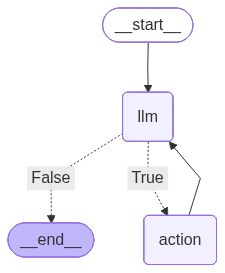

In [17]:
from IPython.display import Image, display

display(Image(agent.graph.get_graph().draw_mermaid_png()))